## Week4: RBF Neural Networks Implementation using TensorFlow and Keras

This notebook serves as part of the **Computer Intelligence and its Applications in Mechatronics** course at **Amirkabir University of Technology**. This notebook demonstrates the implementation of Radial Basis Function (RBF) Neural Networks using TensorFlow and Keras. 

### Workflow
1. **Import Libraries**: Import necessary libraries including TensorFlow, Keras, NumPy, and Matplotlib.
2. **Define Target Function**: Define the target function to generate training data.
3. **Visualize Target Function**: Plot the target function to visualize the training data.
4. **Define RBF Layer**: Create a custom RBF layer class inheriting from `tf.keras.layers.Layer`.
5. **Build RBF Model**: Construct the RBF model using the custom RBF layer and compile it.
6. **Train the Model**: Train the RBF model on the generated training data.
7. **Predict and Visualize**: Use the trained model to make predictions on test data and visualize the results.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Dataset Generation
The dataset is generated using a mixture of gaussian functions.

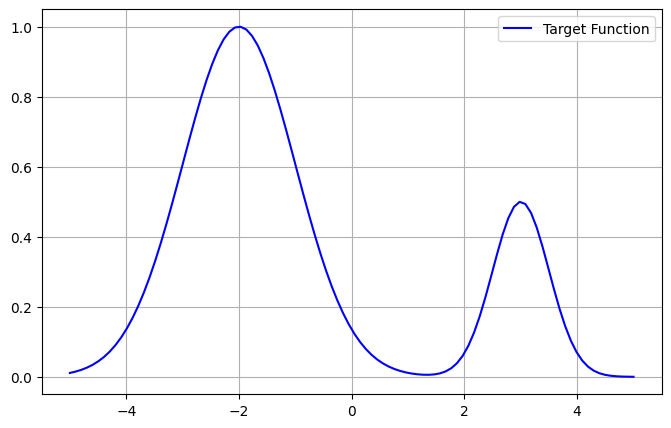

In [2]:
def target_function(x):
    return np.exp(-((x + 2) ** 2) / 2) + 0.5 * np.exp(-((x - 3) ** 2) / 0.5)
x_train = np.linspace(-5, 5, 100).reshape(-1, 1)
y_train = target_function(x_train)

plt.figure(figsize=(8, 5))
plt.plot(x_train, y_train, label="Target Function", color="blue")
plt.grid()
plt.legend()
plt.show()

### RBF Neural Network Model Training

In this section, we define and train the Radial Basis Function (RBF) Neural Network model using TensorFlow and Keras. The model consists of an input layer, a custom RBF layer, and a dense output layer. The training process involves compiling the model with the Adam optimizer and mean squared error loss function, followed by fitting the model to the training data.

- **RBF Layer**: A custom layer that applies radial basis functions to the input data.
- **Model Compilation**: The model is compiled with the Adam optimizer and mean squared error loss function.
- **Model Training**: The model is trained on the generated training data for 500 epochs.

The Following code defines a custom layer for a RBFNN using TensorFlow's Keras API. This custom layer, named RBFLayer, inherits from tf.keras.layers.Layer, which is the base class for all Keras layers.

The `__init__` method initializes the layer with a specified number of units, which determines the number of neurons in the layer. This method calls the parent class's `__init__` method using `super().__init__()` and stores the number of units in an instance variable self.units.

The build method is called once the input shape is known. It initializes three trainable variables: mu, sigma, and kernels.

The mu variable represents the centers of the radial basis functions and is initialized with random values uniformly distributed. 

The sigma variable represents the widths (standard deviations) of the radial basis functions and is initialized to a constant value of 1.0. 

The kernels variable represents the weights of the layer and is initialized with random values uniformly distributed between 0 and 1. All these variables are trainable, meaning their values will be adjusted during the training process.

The call method defines the forward pass of the layer. It computes the output of the layer by applying the radial basis function to the inputs. Specifically, it calculates the Gaussian function for each input.


In [4]:
import tensorflow as tf
from tensorflow.keras.layers import Layer
from tensorflow.keras import ops

class RBFLayer(Layer):
    def __init__(self, units):
        super().__init__()
        self.units = units

    def build(self, input_shape):
        self.mu = self.add_weight(shape=(input_shape[-1], self.units),
                                  initializer=tf.keras.initializers.RandomUniform(minval=0, maxval=5),
                                  trainable=True)

        self.sigma = self.add_weight(shape=(input_shape[-1], self.units),
                                     initializer=tf.keras.initializers.Constant(value=1.0),
                                     trainable=True)

        self.kernels = self.add_weight(shape=(input_shape[-1], self.units),
                                     initializer=tf.keras.initializers.Constant(value=1.0),
                                     trainable=False)

    def call(self, inputs):
        return self.kernels*ops.exp(-ops.square(inputs - self.mu ) / (2 * ops.square(self.sigma)))

#### Training the RBF Neural Network Model
After defining the RBF layer, we can build the RBF Neural Network model using TensorFlow's Keras API. The model consists of an input layer, the custom RBF layer, and a dense output layer. The input shape of the model is specified as the number of features in the training data.

In [5]:
rbf_units = 5

input = tf.keras.Input(shape=(1,))
rbf_layer = RBFLayer(rbf_units)(input)
output = tf.keras.layers.Dense(1)(rbf_layer)
RBF_Model = tf.keras.Model(input, output)

RBF_Model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss='mse')
History = RBF_Model.fit(x_train, y_train, epochs=500, verbose=0)


#### Visualizing the Predictions
Finally, we use the trained model to make predictions on the test data and visualize the results. We plot the target function, the training data, and the model predictions to observe how well the RBF Neural Network has learned the underlying pattern in the data.

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


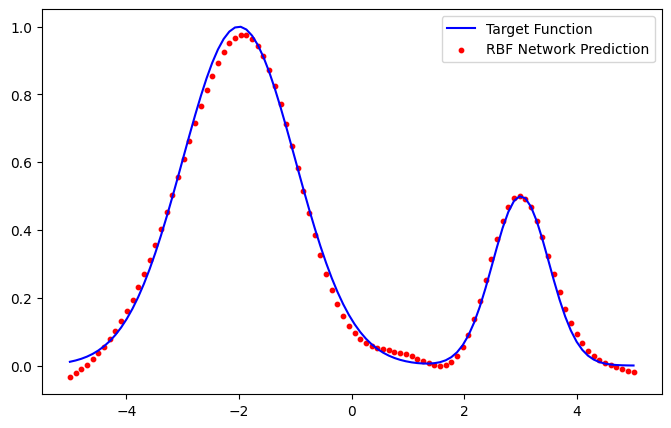

In [6]:
x_test = np.linspace(-5, 5, 100).reshape(-1, 1)
y_pred = RBF_Model.predict(x_test).reshape(-1, 1)

plt.figure(figsize=(8, 5))
plt.plot(x_train, y_train, label="Target Function", color="blue")
plt.scatter(x_test, y_pred, label="RBF Network Prediction", color="red", s=10)
plt.legend()
plt.show()